In [ ]:
from google.colab import drive
drive.mount('/content/drive')


from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/JHU/NewBMEKnee')
DATA    = PROJECT / 'data'
SRC     = PROJECT / 'src'
REPORTS = PROJECT / 'reports'
FIGS    = PROJECT / 'figs'


SRC.mkdir(exist_ok=True)

%cd '/content/drive/MyDrive/JHU/NewBMEKnee'
!mkdir -p data src reports figs

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/JHU/NewBMEKnee


## Data Preparation

In [ ]:
#!/usr/bin/env python3

import pandas as pd
from pathlib import Path

# Paths
project_dir = Path.cwd()
data_dir = project_dir / "data"
output_right = data_dir / "master_v00_right.csv"
output_both = data_dir / "master_v00_both.csv"

# Load raw CSV files
print("Reading raw CSV files...")
semi = pd.read_csv(data_dir / 'oai_kxrsemiquant01.csv', low_memory=False)
pain = pd.read_csv(data_dir / 'oai_koos_womac01.csv', low_memory=False)
demo = pd.read_csv(data_dir / 'oai_enrollee01.csv', low_memory=False)

# Merge on subject ID and date
key_cols = ["src_subject_id", "interview_date"]
df = (
    semi
    .merge(pain, on=key_cols, how="inner", suffixes=('_semi', '_pain'))
    .merge(demo, on="src_subject_id", how="left", suffixes=('', '_demo'))
)

# Remove duplicate columns, keeping priority: semi > none > demo > pain
def dedup_suffix_cols(df):
    priority = {'_semi': 0, '': 1, '_demo': 2, '_pain': 3}
    chosen = {}
    for col in df.columns:
        suffix = next((s for s in priority if col.endswith(s)), '')
        base = (col[:-len(suffix)] if suffix else col).rstrip('_')
        if base not in chosen or priority[suffix] < priority[
            next((s for s in priority if chosen[base].endswith(s)), '')
        ]:
            chosen[base] = col
    df_out = df[list(chosen.values())].copy()
    rename_map = {v: k for k, v in chosen.items() if v != k}
    return df_out.rename(columns=rename_map)

df = dedup_suffix_cols(df)
df = df.loc[:, ~df.columns.duplicated()]

# Standardize key column names
renames = {}
for col in df.columns:
    if col.lower().startswith('src_subject') and col != 'src_subject_id':
        renames[col] = 'src_subject_id'
    if col.lower().startswith('interview_date') and col != 'interview_date':
        renames[col] = 'interview_date'
    if col in ('side_semi', 'side_pain'):
        renames[col] = 'side'
df = df.rename(columns=renames)

# Ensure essential keys exist
for key in ['src_subject_id', 'interview_date', 'side']:
    if key not in df.columns:
        candidates = [c for c in df.columns if c.startswith(key.split('_')[0])]
        if candidates:
            df = df.rename(columns={candidates[0]: key})
        else:
            raise KeyError(f"{key} column missing")

df = df.loc[:, ~df.columns.duplicated()].copy()

# Keep only visit V00
df = df[df['visit'].astype(str).str.upper() == 'V00']

# Build pain score and binary label
def build_pain(df):
    pain_cols = [c for c in df.columns if c.lower().startswith('pain_')]
    df[pain_cols] = df[pain_cols].apply(pd.to_numeric, errors='coerce')

    # KOOS calculation
    koos_raw = df[pain_cols].sum(axis=1, min_count=1)
    koos_count = df[pain_cols].notna().sum(axis=1)
    koos_score = 100 - (100 * koos_raw / (4 * koos_count))

    # WOMAC calculation
    womac_cols = [c for c in pain_cols if c.endswith('_w') or c.endswith('_womac')]
    womac_raw = df[womac_cols].sum(axis=1, min_count=1)
    womac_count = df[womac_cols].notna().sum(axis=1)
    womac_score = 100 - (100 * womac_raw / (4 * womac_count))

    # Prefer KOOS if valid, else WOMAC
    return koos_score.where(koos_count >= 5).combine_first(womac_score.where(womac_count >= 3))

df['pain_score'] = build_pain(df)
df = df.dropna(subset=['pain_score'])
df['pain_bin'] = (df['pain_score'] >= 50).astype(int)

# Compute BMI if weight and height exist
if {'wtkg', 'htm'}.issubset(df.columns):
    df['BMI'] = df['wtkg'] / (df['htm'] ** 2)

# Average duplicates of the same knee
group_keys = ['src_subject_id', 'interview_date', 'side']
num_cols = df.select_dtypes('number').columns
df_num = df.groupby(group_keys, as_index=False)[num_cols].mean()
df_cat = df.drop(columns=num_cols).groupby(group_keys, as_index=False).first()
df = pd.merge(df_num, df_cat, on=group_keys, how='left')

# Split right-side knees and save
df_right = df[df['side'].astype(str).str.strip() == '2']
df_right.to_csv(output_right, index=False)
df.to_csv(output_both, index=False)

print(f"Saved {len(df_right)} rows to {output_right.name}")
print(f"Saved {len(df)} rows to {output_both.name}")

Reading raw CSV files...


<ipython-input-2-c1a83266102c>:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[pain_cols] = df[pain_cols].apply(pd.to_numeric, errors='coerce')
<ipython-input-2-c1a83266102c>:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pain_score'] = build_pain(df)
<ipython-input-2-c1a83266102c>:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

Saved 4483 rows to master_v00_right.csv
Saved 8953 rows to master_v00_both.csv


## Train

In [ ]:
!pip install -q xgboost scikit-learn tqdm pandas


In [ ]:
%%writefile src/train.py
#!/usr/bin/env python3

import argparse
import pickle
import json
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# command-line arguments
parser = argparse.ArgumentParser()
parser.add_argument("--data", default=None, help="path to CSV file")
parser.add_argument("--mode", choices=["struct", "full"], default="struct")
parser.add_argument("--both", action="store_true",
                    help="use both-knees data")
args, _ = parser.parse_known_args()

# determine input file
data_path = Path(args.data) if args.data else Path("data") / \
            ("master_v00_both.csv" if args.both else "master_v00_right.csv")

# prepare output directories
model_dir = Path("models"); model_dir.mkdir(exist_ok=True)
report_dir = Path("reports/tables"); report_dir.mkdir(parents=True, exist_ok=True)

# load dataset
df = pd.read_csv(data_path)

# select features
struct_cols = [c for c in df.columns if c.startswith("xr")]
demo_cols = [c for c in ["sex", "ageyears", "race", "BMI", "site", "side"] if c in df.columns]
X = df[struct_cols].copy()
if args.mode == "full":
    X = X.join(df[demo_cols])

# convert object types and fill missing
for col in X.select_dtypes(include="object"):
    X[col] = X[col].astype("category")
X = X.fillna(X.median(numeric_only=True))
y = df["pain_score"]

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# initialize and train model
model = XGBRegressor(
    tree_method="hist",
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True
)
print(f"Training mode={args.mode}, both={args.both}")
model.fit(X_train, y_train)

# evaluate performance
r2 = r2_score(y_test, model.predict(X_test))
print(f"R² score: {r2:.3f}")

# save the trained model
tag = "both" if args.both else "right"
model_file = model_dir / f"model_{args.mode}_{tag}.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_file}")

# update latex table data
row_file = report_dir / f"r2_rows_{tag}.json"
rows = json.load(row_file.open()) if row_file.exists() else []
rows = [r for r in rows if r.get("mode") != args.mode]
rows.append({"mode": args.mode, "r2": r2})
row_file.write_text(json.dumps(rows, indent=2))

# write latex table if both modes present
if len({r.get("mode") for r in rows}) == 2:
    rows_sorted = sorted(rows, key=lambda x: x.get("mode"))
    delta = rows_sorted[1]["r2"] - rows_sorted[0]["r2"]
    lines = [
        "\\begin{tabular}{lcc}\\toprule",
        f"\\multicolumn{{3}}{{c}}{{{'Both knees' if args.both else 'Right knee only'}}}\\\\midrule",
        "Model & $R^{2}$ & $\\Delta R^{2}$\\\\midrule",
        f"Structure & {rows_sorted[0]['r2']:.3f} & --\\\\",
        f"Struct+Demo & {rows_sorted[1]['r2']:.3f} & {delta:+.3f}\\\\",
        "\\bottomrule\\end{tabular}"
    ]
    tex_file = report_dir / ("r2_both.tex" if args.both else "r2.tex")
    tex_file.write_text("\n".join(lines))
    print(f"Table file written to {tex_file}")


Writing src/train.py


In [ ]:
!python src/train.py --mode struct
!python src/train.py --mode full

Training mode=struct, both=False
R² score: 0.042
Model saved to models/model_struct_right.pkl
Table file written to reports/tables/r2.tex
Training mode=full, both=False
R² score: 0.092
Model saved to models/model_full_right.pkl
Table file written to reports/tables/r2.tex


In [ ]:
%%writefile src/train.py
#!/usr/bin/env python3
"""
train.py — train XGBoost regressors

Usage:
  python src/train.py --data data/master_v00_right.csv --mode struct
  python src/train.py --data data/master_v00_right.csv --mode full
"""

import argparse
import json
import pickle
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--data", default="data/master_v00_right.csv",
        help="path to input CSV"
    )
    parser.add_argument(
        "--mode", choices=["struct", "full"], default="struct",
        help="'struct' uses only structure features; 'full' adds demographics"
    )
    args = parser.parse_known_args()[0]

    data_file = Path(args.data)
    model_dir = Path("models")
    model_dir.mkdir(exist_ok=True)
    table_dir = Path("reports/tables")
    table_dir.mkdir(parents=True, exist_ok=True)

    # load data
    df = pd.read_csv(data_file)

    # select feature columns
    struct_cols = [c for c in df.columns if c.startswith("xr")]
    demo_cols = [c for c in ["sex", "ageyears", "race", "BMI", "site", "side"]
                 if c in df.columns]
    X = df[struct_cols].copy()
    if args.mode == "full":
        X = pd.concat([X, df[demo_cols]], axis=1)

    # convert object columns to category and fill missing values
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype("category")
    X = X.fillna(X.median(numeric_only=True))

    y = df["pain_score"]

    # split into train and test sets
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    # initialize and train XGBoost regressor
    model = XGBRegressor(
        tree_method="hist",
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42,
        enable_categorical=True
    )
    print(f"Training mode = {args.mode}")
    model.fit(X_tr, y_tr)

    # evaluate and display R^2 score
    r2 = r2_score(y_te, model.predict(X_te))
    print(f"Mode {args.mode} R^2 score: {r2:.3f}")

    # save trained model
    model_file = model_dir / f"model_{args.mode}.pkl"
    with open(model_file, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved model to {model_file}")

    # update R2 rows JSON
    row_file = table_dir / "r2_rows.json"
    if row_file.exists():
        rows = json.load(row_file.open())
    else:
        rows = []
    rows = [r for r in rows if r.get("mode") != args.mode]
    rows.append({"mode": args.mode, "r2": r2})
    row_file.write_text(json.dumps(rows, indent=2))

    # write LaTeX table when both modes are available
    modes_done = {r.get("mode") for r in rows}
    if modes_done == {"struct", "full"}:
        sorted_rows = sorted(rows, key=lambda x: x.get("mode"))
        delta = sorted_rows[1]["r2"] - sorted_rows[0]["r2"]
        tex_lines = [
            "\\begin{tabular}{lcc}\\toprule",
            "\\multicolumn{3}{c}{Right knee only}\\midrule",
            "Model & $R^2$ & $\\Delta R^2$\\midrule",
            f"Structure & {sorted_rows[0]['r2']:.3f} & --\\",
            f"Struct+Demo & {sorted_rows[1]['r2']:.3f} & {delta:+.3f}\\",
            "\\bottomrule\\end{tabular}"
        ]
        tex_file = table_dir / "r2.tex"
        tex_file.write_text("\n".join(tex_lines))
        print(f"Wrote LaTeX table to {tex_file}")

if __name__ == "__main__":
    main()


Overwriting src/train.py


## SHAP

In [ ]:
%%writefile src/shap_analysis.py
#!/usr/bin/env python3
"""
shap_analysis.py — generate TreeSHAP plots and tables

Outputs:
  reports/figures/fig_shap_beeswarm.png   # top 20 features beeswarm plot
  outputs/top20.json                      # list of top 20 feature names
  reports/tables/tbl_shap_top.tex         # LaTeX table of top 15 features by mean |SHAP|
"""

import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# paths
DATA_FILE = Path("data/master_v00_right.csv")
MODEL_FILE = Path("models/model_full_right.pkl")
FIG_FILE = Path("reports/figures/fig_shap_beeswarm.png")
TABLE_FILE = Path("reports/tables/tbl_shap_top.tex")
TOP20_FILE = Path("outputs/top20.json")

# ensure directories exist
FIG_FILE.parent.mkdir(parents=True, exist_ok=True)
TABLE_FILE.parent.mkdir(parents=True, exist_ok=True)
TOP20_FILE.parent.mkdir(exist_ok=True)

# load data and model
df = pd.read_csv(DATA_FILE)
model = pickle.load(open(MODEL_FILE, "rb"))

# prepare feature matrix
struct_cols = [c for c in df.columns if c.startswith("xr")]
demo_cols = [c for c in ["sex", "ageyears", "race", "BMI", "site", "side"] if c in df.columns]
X = pd.concat([df[struct_cols], df[demo_cols]], axis=1)
for col in X.select_dtypes(include="object"):
    X[col] = X[col].astype("category")
X = X.fillna(X.median(numeric_only=True))

# sample for speed
sample = X.sample(n=1000, random_state=42)

# compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer(sample)

# determine top 20 features by mean absolute SHAP value
mean_abs = shap_values.abs.mean(axis=0).values
indices = np.argsort(mean_abs)[::-1][:20]
top20 = X.columns[indices].tolist()

# save top20 list
json.dump(top20, open(TOP20_FILE, "w"))
print(f"Saved top-20 features list to {TOP20_FILE}")

# create beeswarm plot
plt.figure(figsize=(6.3, 9))
shap.plots.beeswarm(shap_values[:, indices], max_display=len(top20), show=False)
plt.tight_layout()
plt.savefig(FIG_FILE, dpi=300)
plt.close()
print(f"Saved beeswarm plot to {FIG_FILE}")

# generate LaTeX table for top 15 features
indices15 = indices[:15]
features15 = X.columns[indices15]
values15 = mean_abs[indices15].round(3)

lines = [
    "\\begin{tabular}{lcr}\\toprule",
    "Rank & Feature & $|\mathrm{SHAP}|$\\\\midrule"
]
for i, (feat, val) in enumerate(zip(features15, values15), start=1):
    lines.append(f"{i} & {feat} & {val:.3f}\\\\")
lines.append("\\bottomrule\\end{tabular}")
TABLE_FILE.write_text("\n".join(lines))
print(f"Wrote LaTeX table to {TABLE_FILE}")


Overwriting src/shap_analysis.py


In [ ]:
#!/usr/bin/env python3
"""

shap_analysis.py — generate TreeSHAP plots and tables

Outputs:
  reports/figures/fig_shap_beeswarm.png   # top 20 features beeswarm plot
  outputs/top20.json                      # list of top 20 feature names
  reports/tables/tbl_shap_top.tex         # LaTeX table of top 15 features by mean |SHAP|
"""
import json, pickle, numpy as np, pandas as pd, shap, matplotlib.pyplot as plt
from pathlib import Path

# path
DATA  = Path("data/master_v00_right.csv")
MODEL = Path("models/model_full_right.pkl")
FIG   = Path("reports/figures/fig_shap_beeswarm.png")
TAB   = Path("reports/tables/tbl_shap_top.tex")
OUT20 = Path("outputs/top20.json")

FIG.parent.mkdir(parents=True, exist_ok=True)
TAB.parent.mkdir(parents=True, exist_ok=True)
OUT20.parent.mkdir(exist_ok=True)


df     = pd.read_csv(DATA)
model  = pickle.load(open(MODEL, "rb"))

struct = [c for c in df if c.startswith("xr")]
demo   = ["sex","ageyears","race","BMI","site","side"]
demo   = [c for c in demo if c in df.columns]

X = pd.concat([df[struct], df[demo]], axis=1)
for col in X.select_dtypes("object"):
    X[col] = X[col].astype("category")
X = X.fillna(X.median(numeric_only=True))


sample = X.sample(1000, random_state=42)

explainer   = shap.TreeExplainer(model)
sh_values   = explainer(sample)

# To get Top 20
mean_abs = sh_values.abs.mean(0).values
order20  = np.argsort(mean_abs)[::-1][:20]
top20    = X.columns[order20].tolist()
json.dump(top20, open(OUT20, "w"))
print("saved top-20 list to", OUT20)

#  beeswarm figure
plt.figure(figsize=(6.3,9))
shap.plots.beeswarm(sh_values[:, order20], max_display=len(top20), show=False)
plt.tight_layout()
plt.savefig(FIG, dpi=300)
plt.close()
print("saved beeswarm to", FIG)

# for LaTeX table Top-15
order15 = order20[:20]
table   = pd.DataFrame({
    "Feature": X.columns[order15],
    "MeanAbs": mean_abs[order15].round(3)
})
lines = [
    "\\begin{tabular}{llr}\\toprule", "Rank & Feature & $|\\text{SHAP}|$\\\\\\midrule"
]
for i,(f,v) in enumerate(zip(table.Feature, table.MeanAbs), start=1):
    lines.append(f"{i} & {f} & {v:.3f}\\\\")
lines += ["\\bottomrule\\end{tabular}"]
TAB.write_text("\n".join(lines))
print("wrote table to", TAB)


saved top-20 list to outputs/top20.json
saved beeswarm to reports/figures/fig_shap_beeswarm.png
wrote table to reports/tables/tbl_shap_top.tex


In [ ]:
!python src/shap_analysis.py --model models/model_full.pkl --data data/master_v00_right.csv

Saved top-20 features list to outputs/top20.json
Saved beeswarm plot to reports/figures/fig_shap_beeswarm.png
Wrote LaTeX table to reports/tables/tbl_shap_top.tex


## SANE

### Brute-force SANE

#### K-4

In [ ]:
%%writefile src/sane_bruteforce.py
#!/usr/bin/env python3
"""
sane_bruteforce.py — simple brute‑force search for minimal sufficient and necessary feature subsets
"""

import argparse
import itertools
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from tqdm import tqdm

# parse command-line arguments
def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--model", default="models/model_full_right.pkl",
        help="path to the trained model file"
    )
    parser.add_argument(
        "--data", default="data/master_v00_right.csv",
        help="path to the input CSV data"
    )
    parser.add_argument(
        "--eps", type=float, default=1e-3,
        help="tolerance for prediction difference"
    )
    parser.add_argument(
        "--kmax", type=int, default=6,
        help="maximum size of feature combos to try"
    )
    parser.add_argument(
        "--nsamp", type=int, default=200,
        help="number of random samples to analyze"
    )
    return parser.parse_known_args()[0]


def load_data(model_path, data_path):
    """
    Load the model and the dataset, return both.
    """
    clf = pickle.load(open(model_path, "rb"))
    df = pd.read_csv(data_path)
    return clf, df


def prepare_features(df):
    """
    Select structural features (columns starting with 'xr') and some demographics,
    convert object columns to categorical, and fill missing values.
    """
    struct_cols = [c for c in df.columns if c.startswith("xr")]
    demo_cols = [c for c in ["sex", "ageyears", "race", "site", "side"]
                 if c in df.columns]
    X = df[struct_cols + demo_cols].copy()

    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype("category")
    X = X.fillna(X.median(numeric_only=True))
    return X


def predict_row(clf, row_df):
    """
    Predict a single row of data; return scalar.
    """
    for col in row_df.select_dtypes(include="object").columns:
        row_df[col] = row_df[col].astype("category")
    return float(clf.predict(row_df, validate_features=False)[0])


def brute_force_instance(idx, X, clf, kmax, eps):
    """
    For row at index idx in X, find minimal sufficient set S and
    minimal necessary set N by brute-force up to size kmax.
    Returns a dict with original prediction, S, and N.
    """
    row = X.iloc[[idx]].copy()
    original = predict_row(clf, row)
    features = list(row.columns)

    # find S: smallest subset that keeps prediction within eps
    S_min = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in features:
                if f not in combo:
                    if isinstance(test[f].dtype, CategoricalDtype):
                        test[f] = test[f].cat.categories[0]
                    else:
                        test[f] = 0
            if abs(predict_row(clf, test) - original) < eps:
                S_min = list(combo)
                break
        if S_min:
            break

    # find N: smallest subset whose removal changes prediction by > eps
    N_min = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in combo:
                if isinstance(test[f].dtype, CategoricalDtype):
                    test[f] = test[f].cat.categories[0]
                else:
                    test[f] = 0
            if abs(predict_row(clf, test) - original) > eps:
                N_min = list(combo)
                break
        if N_min:
            break

    return {"y_hat": original, "S": S_min, "N": N_min}


def main():
    args = parse_args()
    clf, df = load_data(args.model, args.data)
    X = prepare_features(df)

    # pick random indices to process
    rng = np.random.RandomState(0)
    idxs = rng.choice(X.index, size=min(args.nsamp, len(X)), replace=False)

    print(f"Brute-force search on {len(idxs)} samples "
          f"(kmax={args.kmax}, eps={args.eps})")

    results = {}
    for i in tqdm(idxs):
        results[int(i)] = brute_force_instance(i, X, clf, args.kmax, args.eps)

    # save output
    out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
    out_file = out_dir / "sane_samples.json"
    with open(out_file, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved results to {out_file}")


if __name__ == "__main__":
    main()


Overwriting src/sane_bruteforce.py


In [ ]:
!python src/sane_bruteforce.py --nsamp 100 --kmax 4 --eps 0.5

#### K-5

In [ ]:
%%writefile src/sane_bruteforce.py
#!/usr/bin/env python3
"""
SANE_bruteforce.py — simple brute-force search for minimal sufficient and necessary feature subsets

Usage:
  python src/sane_bruteforce.py --model models/model_full_right.pkl \
                                 --data data/master_v00_right.csv \
                                 --eps 1e-3 --kmax 6 --nsamp 200
"""

import argparse
import itertools
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from tqdm import tqdm

def main():
    # parse command-line options
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--model", default="models/model_full_right.pkl",
        help="path to the trained model file"
    )
    parser.add_argument(
        "--data", default="data/master_v00_right.csv",
        help="path to the input CSV file"
    )
    parser.add_argument(
        "--eps", type=float, default=1e-3,
        help="tolerance for prediction difference"
    )
    parser.add_argument(
        "--kmax", type=int, default=6,
        help="max subset size to test"
    )
    parser.add_argument(
        "--nsamp", type=int, default=200,
        help="number of random samples to analyze"
    )
    args = parser.parse_known_args()[0]

    # load model and data
    print("Loading model and data...")
    model = pickle.load(open(args.model, "rb"))
    df = pd.read_csv(args.data)

    # pick structure and demo features
    struct_cols = [c for c in df.columns if c.startswith("xr")]
    demo_cols = [c for c in ["sex", "ageyears", "race", "site", "side"] if c in df.columns]
    X = df[struct_cols + demo_cols].copy()

    # convert text columns to categorical and fill missing
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype("category")
    X = X.fillna(X.median(numeric_only=True))

    # helper: predict a single row
    def predict_row(row_df):
        # ensure categories match model expectations
        for col in row_df.select_dtypes(include="object").columns:
            row_df[col] = row_df[col].astype("category")
        return float(model.predict(row_df, validate_features=False)[0])

    # helper: brute-force one instance
    def brute_force(idx):
        row = X.iloc[[idx]].copy()
        orig = predict_row(row)
        features = list(row.columns)

        # find smallest sufficient set S
        S_min = None
        for size in range(1, args.kmax + 1):
            for combo in itertools.combinations(features, size):
                test = row.copy()
                # reset features not in combo
                for f in features:
                    if f not in combo:
                        if isinstance(test[f].dtype, CategoricalDtype):
                            test[f] = test[f].cat.categories[0]
                        else:
                            test[f] = 0
                if abs(predict_row(test) - orig) < args.eps:
                    S_min = list(combo)
                    break
            if S_min:
                break

        # find smallest necessary set N
        N_min = None
        for size in range(1, args.kmax + 1):
            for combo in itertools.combinations(features, size):
                test = row.copy()
                for f in combo:
                    if isinstance(test[f].dtype, CategoricalDtype):
                        test[f] = test[f].cat.categories[0]
                    else:
                        test[f] = 0
                if abs(predict_row(test) - orig) > args.eps:
                    N_min = list(combo)
                    break
            if N_min:
                break

        return {"y_hat": orig, "S": S_min, "N": N_min}

    # choose a random subset of indices
    rng = np.random.RandomState(0)
    idxs = rng.choice(X.index, size=min(args.nsamp, len(X)), replace=False)
    print(f"Processing {len(idxs)} samples (kmax={args.kmax}, eps={args.eps})")

    results = {}
    for i in tqdm(idxs, desc="Brute force"):  # run brute-force on each
        results[int(i)] = brute_force(i)

    # save results as JSON
    out_dir = Path("outputs")
    out_dir.mkdir(exist_ok=True)
    out_file = out_dir / "sane_samples_5.json"


Overwriting src/sane_bruteforce.py


In [ ]:
%%writefile src/sane_bruteforce.py
#!/usr/bin/env python3
"""
sane_bruteforce.py — simple brute-force search for minimal sufficient and necessary subsets

Usage:
  python src/sane_bruteforce.py \
    --model models/model_full_right.pkl \
    --data data/master_v00_right.csv \
    --eps 1e-3 --kmax 6 --nsamp 200
"""
import argparse
import itertools
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from tqdm import tqdm

# parse command-line options
p = argparse.ArgumentParser()
p.add_argument(
    "--model", default="models/model_full_right.pkl",
    help="path to trained model"
)
p.add_argument(
    "--data", default="data/master_v00_right.csv",
    help="path to input CSV data"
)
p.add_argument(
    "--eps", type=float, default=1e-3,
    help="tolerance for prediction difference"
)
p.add_argument(
    "--kmax", type=int, default=6,
    help="maximum feature subset size to test"
)
p.add_argument(
    "--nsamp", type=int, default=200,
    help="number of random samples to analyze"
)
args = p.parse_known_args()[0]

# load model and dataset
model = pickle.load(open(args.model, "rb"))
df = pd.read_csv(args.data)

# prepare features: structural + demographic
struct = [c for c in df.columns if c.startswith("xr")]
demo = [c for c in ["sex", "ageyears", "race", "site", "side"] if c in df.columns]
X = df[struct + demo].copy()

# convert object columns to category, fill missing
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")
X = X.fillna(X.median(numeric_only=True))

def predict(row_df):
    """
    Predict for a single-row DataFrame, returning a scalar.
    """
    for col in row_df.select_dtypes(include="object").columns:
        row_df[col] = row_df[col].astype("category")
    return float(model.predict(row_df, validate_features=False)[0])

def brute(i, kmax, eps):
    """
    Find minimal sufficient set S and necessary set N for instance i.
    """
    row = X.iloc[[i]].copy()
    original = predict(row)
    features = row.columns

    # find S: smallest subset keeping prediction within eps
    Smin = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in features:
                if f not in combo:
                    if isinstance(test[f].dtype, CategoricalDtype):
                        test[f] = test[f].cat.categories[0]
                    else:
                        test[f] = 0
            if abs(predict(test) - original) < eps:
                Smin = list(combo)
                break
        if Smin:
            break

    # find N: smallest subset whose removal alters prediction more than eps
    Nmin = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in combo:
                if isinstance(test[f].dtype, CategoricalDtype):
                    test[f] = test[f].cat.categories[0]
                else:
                    test[f] = 0
            if abs(predict(test) - original) > eps:
                Nmin = list(combo)
                break
        if Nmin:
            break

    return {"y_hat": original, "S": Smin, "N": Nmin}

# select random sample indices
rng = np.random.RandomState(0)
idxs = rng.choice(X.index, size=min(args.nsamp, len(X)), replace=False)
print(f"Processing {len(idxs)} samples (kmax={args.kmax}, eps={args.eps})")

# run brute-force analysis
tresults = {int(i): brute(i, args.kmax, args.eps) for i in tqdm(idxs, desc="Brute force")}

# save output
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
json.dump(tresults, open("outputs/sane_samples_5.json", "w"))
print("Saved results to outputs/sane_samples_5.json")


Overwriting src/sane_bruteforce.py


In [ ]:
!python src/sane_bruteforce.py --nsamp 100 --kmax 5 --eps 0.5


#### K - 6

In [ ]:
%%writefile src/sane_bruteforce.py
#!/usr/bin/env python3
"""
sane_bruteforce.py — simple brute-force search for minimal sufficient and necessary subsets

Usage:
  python src/sane_bruteforce.py \
    --model models/model_full_right.pkl \
    --data data/master_v00_right.csv \
    --eps 1e-3 --kmax 6 --nsamp 200
"""
import argparse
import itertools
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from tqdm import tqdm

# parse command-line options
p = argparse.ArgumentParser()
p.add_argument(
    "--model", default="models/model_full_right.pkl",
    help="path to trained model"
)
p.add_argument(
    "--data", default="data/master_v00_right.csv",
    help="path to input CSV data"
)
p.add_argument(
    "--eps", type=float, default=1e-3,
    help="tolerance for prediction difference"
)
p.add_argument(
    "--kmax", type=int, default=6,
    help="maximum feature subset size to test"
)
p.add_argument(
    "--nsamp", type=int, default=200,
    help="number of random samples to analyze"
)
args = p.parse_known_args()[0]

# load model and dataset
model = pickle.load(open(args.model, "rb"))
df = pd.read_csv(args.data)

# prepare features: structural + demographic
struct = [c for c in df.columns if c.startswith("xr")]
demo = [c for c in ["sex", "ageyears", "race", "site", "side"] if c in df.columns]
X = df[struct + demo].copy()

# convert object columns to category, fill missing
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")
X = X.fillna(X.median(numeric_only=True))

def predict(row_df):
    """
    Predict for a single-row DataFrame, returning a scalar.
    """
    for col in row_df.select_dtypes(include="object").columns:
        row_df[col] = row_df[col].astype("category")
    return float(model.predict(row_df, validate_features=False)[0])

def brute(i, kmax, eps):
    """
    Find minimal sufficient set S and necessary set N for instance i.
    """
    row = X.iloc[[i]].copy()
    original = predict(row)
    features = row.columns

    # find S: smallest subset keeping prediction within eps
    Smin = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in features:
                if f not in combo:
                    if isinstance(test[f].dtype, CategoricalDtype):
                        test[f] = test[f].cat.categories[0]
                    else:
                        test[f] = 0
            if abs(predict(test) - original) < eps:
                Smin = list(combo)
                break
        if Smin:
            break

    # find N: smallest subset whose removal alters prediction more than eps
    Nmin = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in combo:
                if isinstance(test[f].dtype, CategoricalDtype):
                    test[f] = test[f].cat.categories[0]
                else:
                    test[f] = 0
            if abs(predict(test) - original) > eps:
                Nmin = list(combo)
                break
        if Nmin:
            break

    return {"y_hat": original, "S": Smin, "N": Nmin}

# select random sample indices
rng = np.random.RandomState(0)
idxs = rng.choice(X.index, size=min(args.nsamp, len(X)), replace=False)
print(f"Processing {len(idxs)} samples (kmax={args.kmax}, eps={args.eps})")

# run brute-force analysis
tresults = {int(i): brute(i, args.kmax, args.eps) for i in tqdm(idxs, desc="Brute force")}

# save output
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
json.dump(tresults, open("outputs/sane_samples_6.json", "w"))
print("Saved results to outputs/sane_samples_6.json")


Overwriting src/sane_bruteforce.py


In [ ]:

!python src/sane_bruteforce.py --nsamp 100 --kmax 5 --eps 0.5


Processing 100 samples (kmax=5, eps=0.5)
Brute force:  14% 14/100 [08:47<1:11:35, 49.95s/it]

#### K-7

In [ ]:
%%writefile src/sane_bruteforce.py
#!/usr/bin/env python3
"""
sane_bruteforce.py — simple brute-force search for minimal sufficient and necessary subsets

Usage:
  python src/sane_bruteforce.py \
    --model models/model_full_right.pkl \
    --data data/master_v00_right.csv \
    --eps 1e-3 --kmax 6 --nsamp 200
"""
import argparse
import itertools
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from tqdm import tqdm

# parse command-line options
p = argparse.ArgumentParser()
p.add_argument(
    "--model", default="models/model_full_right.pkl",
    help="path to trained model"
)
p.add_argument(
    "--data", default="data/master_v00_right.csv",
    help="path to input CSV data"
)
p.add_argument(
    "--eps", type=float, default=1e-3,
    help="tolerance for prediction difference"
)
p.add_argument(
    "--kmax", type=int, default=6,
    help="maximum feature subset size to test"
)
p.add_argument(
    "--nsamp", type=int, default=200,
    help="number of random samples to analyze"
)
args = p.parse_known_args()[0]

# load model and dataset
model = pickle.load(open(args.model, "rb"))
df = pd.read_csv(args.data)

# prepare features: structural + demographic
struct = [c for c in df.columns if c.startswith("xr")]
demo = [c for c in ["sex", "ageyears", "race", "site", "side"] if c in df.columns]
X = df[struct + demo].copy()

# convert object columns to category, fill missing
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")
X = X.fillna(X.median(numeric_only=True))

def predict(row_df):
    """
    Predict for a single-row DataFrame, returning a scalar.
    """
    for col in row_df.select_dtypes(include="object").columns:
        row_df[col] = row_df[col].astype("category")
    return float(model.predict(row_df, validate_features=False)[0])

def brute(i, kmax, eps):
    """
    Find minimal sufficient set S and necessary set N for instance i.
    """
    row = X.iloc[[i]].copy()
    original = predict(row)
    features = row.columns

    # find S: smallest subset keeping prediction within eps
    Smin = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in features:
                if f not in combo:
                    if isinstance(test[f].dtype, CategoricalDtype):
                        test[f] = test[f].cat.categories[0]
                    else:
                        test[f] = 0
            if abs(predict(test) - original) < eps:
                Smin = list(combo)
                break
        if Smin:
            break

    # find N: smallest subset whose removal alters prediction more than eps
    Nmin = None
    for size in range(1, kmax + 1):
        for combo in itertools.combinations(features, size):
            test = row.copy()
            for f in combo:
                if isinstance(test[f].dtype, CategoricalDtype):
                    test[f] = test[f].cat.categories[0]
                else:
                    test[f] = 0
            if abs(predict(test) - original) > eps:
                Nmin = list(combo)
                break
        if Nmin:
            break

    return {"y_hat": original, "S": Smin, "N": Nmin}

# select random sample indices
rng = np.random.RandomState(0)
idxs = rng.choice(X.index, size=min(args.nsamp, len(X)), replace=False)
print(f"Processing {len(idxs)} samples (kmax={args.kmax}, eps={args.eps})")

# run brute-force analysis
tresults = {int(i): brute(i, args.kmax, args.eps) for i in tqdm(idxs, desc="Brute force")}

# save output
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
json.dump(tresults, open("outputs/sane_samples_7.json", "w"))
print("Saved results to outputs/sane_samples_7.json")


Overwriting src/sane_bruteforce.py


In [ ]:
!python src/sane_bruteforce.py --nsamp 100 --kmax 7 --eps 0.5


Training mode = struct
Mode struct R^2 score: 0.042
Saved model to models/model_struct.pkl
Training mode = full
Mode full R^2 score: 0.092
Saved model to models/model_full.pkl
Wrote LaTeX table to reports/tables/r2.tex
Processing 100 samples (kmax=7, eps=0.5)
Brute force:   2% 2/100 [00:09<09:05,  5.56s/it]Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/xgboost/config.py", line 184, in config_context
    yield
  File "/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py", line 1248, in predict
    predts = self.get_booster().inplace_predict(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 2512, in inplace_predict
    data, fns, _ = _transform_pandas_df(data, enable_categorical)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/data.py", line 611, in _transform_pandas_df
    arrays = pandas_transform_data

#### SANE 4/5/6/7 Compare

In [ ]:
%%writefile src/sane_robust.py
#!/usr/bin/env python3

import json, collections, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path


files = {
    4: "outputs/sane_samples.json",
    5: "outputs/sane_samples_5.json",
    6: "outputs/sane_samples_6.json",
    7: "outputs/sane_samples_7.json",
}

records = []
for k, fp in files.items():
    data = json.load(open(fp))
    n   = len(data)
    cntS = collections.Counter()
    cntN = collections.Counter()
    for v in data.values():
        if v["S"]: cntS.update(set(v["S"]))
        if v["N"]: cntN.update(set(v["N"]))
    for feat in set(cntS) | set(cntN):
        records.append({
            "k": k,
            "feature": feat,
            "pct_S": 100*cntS[feat]/n,
            "pct_N": 100*cntN[feat]/n,
        })

df = pd.DataFrame(records)


top_feats = (df.groupby("feature")["pct_S"].max()
               .sort_values(ascending=False)
               .head(10).index)
fig, ax = plt.subplots(figsize=(8,4))
width = 0.18
ks = sorted(files)
for i,k in enumerate(ks):
    sub = df[(df.k==k)&(df.feature.isin(top_feats))]
    ax.bar([x+i*width for x in range(len(top_feats))], sub["pct_S"],
           width, label=f"k={k}")
ax.set_xticks([x+width*1.5 for x in range(len(top_feats))])
ax.set_xticklabels(top_feats, rotation=45, ha="right")
ax.set_ylabel("% knees where feature ∈ S")
ax.set_title("Sufficient-set frequency vs. k")
ax.legend()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
plt.tight_layout(); plt.savefig("reports/figures/fig_sane_robust.png", dpi=300)
print(" fig_sane_robust.png saved")


tbl = (df[df.feature.isin(top_feats)]
         .pivot(index="feature", columns="k", values="pct_S")
         .round(1).fillna(0))
latex = tbl.to_latex(column_format="l"+"c"*len(ks),
                     caption="Frequency (\\%) that each feature appears in a Sufficient set under different $k_{\\max}$.",
                     label="tab:sane-robust")
Path("reports/tables").mkdir(parents=True, exist_ok=True)
Path("reports/tables/sane_robust.tex").write_text(latex)
print("sane_robust.tex written")


Overwriting src/sane_robust.py


In [ ]:
!python src/sane_robust.py


 fig_sane_robust.png saved
sane_robust.tex written


#### S/N Bar Diagram + table

In [ ]:
%%writefile src/sane_global_plot.py
#!/usr/bin/env python3
"""
sane_global_plot.py — create bar chart and LaTeX table summarizing S/N frequencies
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the brute-force results (S and N subsets)
data_file = Path("outputs/sane_samples_5.json")
print(f"Loading data from {data_file}")
raw_data = json.load(open(data_file))

# Build a list of records with S and N lists
records = []
for entry in raw_data.values():
    S = entry.get("S") or []  # sufficient subset
    N = entry.get("N") or []  # necessary subset
    records.append({"S": S, "N": N})
df = pd.DataFrame(records)

# Determine all features and compute frequencies
features = sorted({feat for lst in df["S"].tolist() + df["N"].tolist() for feat in lst})
freq_S = {feat: df["S"].apply(lambda lst: feat in lst).mean() for feat in features}
freq_N = {feat: df["N"].apply(lambda lst: feat in lst).mean() for feat in features}
# Sort features by how often they appear in S
order = sorted(features, key=lambda feat: freq_S[feat], reverse=True)

# Plot grouped bar chart of P(S) and P(N)
plt.figure(figsize=(7, 4.5))
x = np.arange(len(order))
vals_S = [freq_S[f] * 100 for f in order]
vals_N = [freq_N[f] * 100 for f in order]
plt.bar(x - 0.15, vals_S, width=0.3, label="Sufficient")
plt.bar(x + 0.15, vals_N, width=0.3, label="Necessary")
plt.xticks(x, order, rotation=60, ha="right")
plt.ylabel("Percentage of samples (%)")
plt.legend()
plt.tight_layout()

# Save figure
fig_dir = Path("reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / "fig_sane_bar.png"
plt.savefig(fig_path, dpi=300)
plt.close()
print(f"Saved bar chart to {fig_path}")

# Generate LaTeX table with probabilities
table_dir = Path("reports/tables")
table_dir.mkdir(parents=True, exist_ok=True)
rows = []
for feat in order:
    pS = freq_S[feat] * 100
    pN = freq_N[feat] * 100
    rows.append(f"{feat} & {pS:.1f}\\% & {pN:.1f}\\\\")

latex_lines = [
    "\\begin{tabular}{lcc}\\toprule",
    "Feature & $P(S)$ & $P(N)$\\\\midrule"
] + rows + ["\\bottomrule\\end{tabular}"]

table_path = table_dir / "sane_full.tex"
table_path.write_text("\n".join(latex_lines))
print(f"Wrote LaTeX table to {table_path}")


Writing src/sane_global_plot.py


## Fairness Evaluation

###Pain Score Black VS White
Objective: To support the "low pain tolerance/reporting" explanation, Black subjects still report significantly less pain than White subjects, given comparable structural severity.

#### 结构匹配 (Propensity / 1:1)

In [ ]:
%%writefile src/propensity_score_matching.py
#!/usr/bin/env python3
"""
propensity_score_matching.py — estimate propensity scores and perform 1:1 nearest-neighbor matching

Steps:
 1. Impute missing values in structural features
 2. Train a logistic regression for propensity scores
 3. Match treated vs. control samples without replacement
"""

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

# Load data
# Read the master dataset for right knees
data_path = Path("data/master_v00_right.csv")
df = pd.read_csv(data_path)

# Select structural features (columns starting with 'xr')
struct_cols = [col for col in df.columns if col.startswith("xr")]

# impute missing values
# Use median strategy for numeric features
imputer = SimpleImputer(strategy="median")
X_struct = pd.DataFrame(
    imputer.fit_transform(df[struct_cols]),
    columns=struct_cols
)

# Train propensity score model
# Binary outcome: treated group is Black/African American
treatment_flag = df["race"] == "Black or African American"

logit = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)
# Fit on structural features
logit.fit(X_struct, treatment_flag)
# Predict probability of being treated
df["pscore"] = logit.predict_proba(X_struct)[:, 1]

#  1:1 nearest-neighbor matching
# Separate treated and control samples
treated = df[treatment_flag].copy()
control = df[~treatment_flag].copy()

# Fit nearest-neighbors on control propensity scores
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["pscore"]])

# Find the best match for each treated sample
distances, indices = nn.kneighbors(treated[["pscore"]])
matched_control_idx = control.iloc[indices.flatten()].index

# Combine treated and their matched controls
matched = pd.concat([
    treated.reset_index(drop=True),
    control.loc[matched_control_idx].reset_index(drop=True)
], axis=0)

# Report number of matched pairs
num_pairs = len(matched) // 2
print(f"Number of matched pairs: {num_pairs}")


Writing src/propensity_score_matching.py


In [ ]:
%%writefile src/propensity_score_matching.py
#!/usr/bin/env python3
"""
propensity_score_matching.py — estimate propensity scores and perform 1:1 nearest-neighbor matching

Steps:
 1. Impute missing values in structural features
 2. Train a logistic regression model for propensity scores
 3. Match treated and control samples using nearest neighbors
"""

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

# Load the data
data_file = Path("data/master_v00_right.csv")
df = pd.read_csv(data_file)

# Select structural features (columns starting with 'xr')
struct_cols = [col for col in df.columns if col.startswith("xr")]

# Step 1: Impute missing values with column medians
imputer = SimpleImputer(strategy="median")
X_struct = pd.DataFrame(
    imputer.fit_transform(df[struct_cols]),
    columns=struct_cols
)

# Step 2: Train logistic regression for propensity scoring
treated_flag = df["race"] == "Black or African American"
log_model = LogisticRegression(max_iter=1000, solver="lbfgs")
log_model.fit(X_struct, treated_flag)
# Assign propensity scores to the DataFrame
df["pscore"] = log_model.predict_proba(X_struct)[:, 1]

# Step 3: Perform 1:1 nearest-neighbor matching
#   - treated group: Black or African American
#   - control group: White

treated = df[treated_flag].copy()
control = df[~treated_flag].copy()

# Fit nearest neighbors on control propensity scores
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["pscore"]])

# Find the best control match for each treated sample
dists, idxs = nn.kneighbors(treated[["pscore"]])
matched_idx = control.iloc[idxs.flatten()].index

# Combine treated and matched control samples
matched = pd.concat([
    treated.reset_index(drop=True),
    control.loc[matched_idx].reset_index(drop=True)
], ignore_index=True)

# Report the number of matched pairs
print(f"Number of matched pairs: {len(matched) // 2}")


Overwriting src/propensity_score_matching.py


#### Structure → Pain regression residuals Computation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import pandas as pd

df = pd.read_csv("data/master_v00_right.csv")
struct_cols = [c for c in df if c.startswith("xr")]


X = df[struct_cols]
X = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=struct_cols)

y = df["pain_score"]



model  = LinearRegression().fit(X, y)
resid  = y - model.predict(X)

df["resid"] = resid

print(df.groupby("race")["resid"].mean())


race
Asian                        4.370727
Black or African American   -8.428397
Other Non-White             -4.625509
Unknown or not reported     -7.235741
White                        1.880892
Name: resid, dtype: float64


#### Boxplot of pain vs KL rating

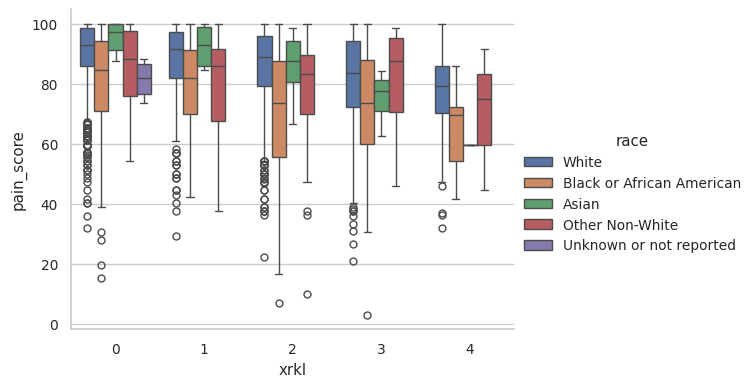

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.catplot(data=df, x="xrkl", y="pain_score", hue="race",
            kind="box", height=4, aspect=1.4)
plt.savefig("reports/figures/pain_vs_kl_by_race.png")


In [ ]:
#!/usr/bin/env python3
"""
descriptives.py —— Pain  + Pain vs KL boxplot
  ├ reports/tables/pain_by_race.tex
  └ reports/figures/
      ├ pain_dist_by_race.png
      └ pain_vs_kl_by_race.png
"""
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer

sns.set(style="whitegrid", font_scale=.9)

DATA = Path("data/master_v00_right.csv")
TAB  = Path("reports/tables"); TAB.mkdir(parents=True, exist_ok=True)
FIG  = Path("reports/figures"); FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA)

# Pain description table
race_order = ["White", "Black or African American",
              "Asian", "Other Non-White", "Unknown or not reported"]
df["race"] = pd.Categorical(df["race"], categories=race_order, ordered=True)

tbl = (df.groupby("race")["pain_score"]
         .agg(["count","mean","median","std"]).round(2)
         .rename(columns={"count":"$n$",
                          "mean":"均值","median":"中位数","std":"标准差"}))
(TAB/"pain_by_race.tex").write_text(tbl.to_latex(column_format="lcccc", escape=False))
print("tables/pain_by_race.tex")

# Pain density
plt.figure(figsize=(6,3.5))
for r in race_order:
    sns.kdeplot(df.loc[df["race"]==r,"pain_score"], label=r, linewidth=1.5)
plt.xlabel("Pain score (0–100)"); plt.ylabel("Density")
plt.legend(title="race", fontsize=8); plt.tight_layout()
plt.savefig(FIG/"pain_dist_by_race.png", dpi=300); plt.close()
print("figures/pain_dist_by_race.png")

# Pain vs KL

df["xrkl"] = SimpleImputer(strategy="most_frequent").fit_transform(
                df[["xrkl"]]).astype(int)
g = sns.catplot(data=df, x="xrkl", y="pain_score", hue="race",
                kind="box", height=4, aspect=1.4, order=[0,1,2,3,4])
g.set_axis_labels("xrkl", "pain_score")
g._legend.set_title("race")
plt.tight_layout()
plt.savefig(FIG/"pain_vs_kl_by_race.png", dpi=300); plt.close()
print("figures/pain_vs_kl_by_race.png")


<ipython-input-19-bf5b13e498fb>:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = (df.groupby("race")["pain_score"]


tables/pain_by_race.tex
figures/pain_dist_by_race.png
figures/pain_vs_kl_by_race.png


##Appendix

In [ ]:
# scripts/build_appendix_tables.py
import pandas as pd, re, json
from pathlib import Path

DATA = Path("data")
semi = pd.read_csv(DATA/"oai_kxrsemiquant01.csv",  nrows=1, low_memory=False)
pain = pd.read_csv(DATA/"oai_koos_womac01.csv",    nrows=1, low_memory=False)

# XR radiographic variables
xr_cols   = [c for c in semi.columns if c.startswith("xr")]

xr_table = "\\begin{tabular}{ll}\\toprule\nID & Description\\\\\\midrule\n"
for c in xr_cols:
    xr_table += f"{c} & -- \\\\\n"
xr_table += "\\bottomrule\\end{tabular}\n"
Path("reports/tables").mkdir(parents=True, exist_ok=True)
(Path("reports/tables/xr_map.tex")).write_text(xr_table)

# KOOS / WOMAC pain items
pain_items = [c for c in pain.columns if re.match(r"(pain|diff|sym|stiff|qol)_", c)]
koos_table = "\\begin{tabular}{ll}\\toprule\nItem & Questionnaire\\\\\\midrule\n"
for c in pain_items:
    q = "KOOS" if c.startswith(("pain_rk","sym_rk","diff_rk","qol")) else "WOMAC"
    koos_table += f"{c} & {q} \\\\\n"
koos_table += "\\bottomrule\\end{tabular}\n"
(Path("reports/tables/koos_items.tex")).write_text(koos_table)

print("generate xr_map.tex  and  koos_items.tex")


generate xr_map.tex  and  koos_items.tex


In [ ]:
#!/usr/bin/env python3

from pathlib import Path


XR_DESC = {
    "xrkl"   : "Kellgren--Lawrence global grade (0--4)",
    "xrjsl"  : "Joint–space narrowing, lateral tibiofemoral",
    "xrjsm"  : "Joint–space narrowing, medial tibiofemoral",
    "xrosfl" : "Osteophyte size, lateral femoral condyle",
    "xrosfm" : "Osteophyte size, medial femoral condyle",
    "xrostl" : "Osteophyte size, lateral tibial plateau",
    "xrostm" : "Osteophyte size, medial tibial plateau",
    "xrscfl" : "Subchondral sclerosis, lateral femoral",
    "xrscfm" : "Subchondral sclerosis, medial femoral",
    "xrsctl" : "Subchondral sclerosis, lateral tibial",
    "xrsctm" : "Subchondral sclerosis, medial tibial",
    "xrcyfl" : "Subchondral cysts, lateral femoral",
    "xrcyfm" : "Subchondral cysts, medial femoral",
    "xrcytl" : "Subchondral cysts, lateral tibial",
    "xrcytm" : "Subchondral cysts, medial tibial",
    "xrattl" : "Bone attrition, lateral tibial",
    "xrat tm": "Bone attrition, medial tibial",
    "xrchl"  : "Chondrocalcinosis, lateral compartment",
    "xrchm"  : "Chondrocalcinosis, medial compartment",

}


lines = ["\\begin{tabular}{ll}\\toprule",
         "ID & Description\\\\\\midrule"]
for k, v in XR_DESC.items():
    lines.append(f"{k} & {v} \\\\")
lines.append("\\bottomrule\\end{tabular}\n")

Path("reports/tables").mkdir(parents=True, exist_ok=True)
Path("reports/tables/xr_map.tex").write_text("\n".join(lines))
print("write in reports/tables/xr_map.tex")


write in reports/tables/xr_map.tex
